In [1]:
using PlotlyJS
using Infiltrator
using XLSX
include("../model/pre_processing.jl")

# include("../../utils/main.jl")


generate_energy_reserves_cumulative (generic function with 1 method)

In [2]:
function load_deterministic_data(day, input_folder, ε=nothing, ρ=nothing)
    gen_df, loads_multi_df, gen_variable_multi_df, storage_df, random_loads_multi_df = generate_input_data(day, input_folder)
    # required_reserve = generate_reserves(loads_multi_df, gen_variable_multi_df, reserve)
    file = joinpath(input_folder, G_UC_DATA, "Reserve.csv")
    if isfile(file)
        println("Reserve file found, loading reserves...")                            
        required_reserve = filter_day(day, CSV.read(file, DataFrame))
    else
        println("Reserve file not found, generating reserves...")
        required_reserve = generate_reserves(loads_multi_df, gen_variable_multi_df, ε, ρ)
    end
    random_loads_multi_df = filter_demand(loads_multi_df, random_loads_multi_df, required_reserve)
    return gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve
end

function load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
    file = joinpath(input_folder, G_UC_DATA, "Energy reserve.csv")
    if isfile(file)
        println("Energy reserve file found, loading reserves...")
        return filter_day(day, CSV.read(file, DataFrame))
    else
        println("Energy reserve file not found, generating reserves...")
        return  generate_energy_reserves(loads_multi_df, gen_variable_multi_df, ε, ρ)
    end
end

load_energy_reserve (generic function with 1 method)

In [34]:
day = 7
input_folder = "../input/base_case_increased_storage_energy_v7.0.8.0"
ε = 0.025
ρ = 0.8
gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder, ε, ρ)
required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
;

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...


Checking that max_{i in T} ER[s,i,t]<=sum(R[S,τ], τ<=t) 

In [35]:
max_required_energy_reserve = combine(groupby(required_energy_reserve, [:t_hour]),[:reserve_up_MW, :reserve_down_MW].=> maximum, renamecols = false)
rename!(max_required_energy_reserve,:t_hour => :hour)
cumsum_required_reserve = combine(required_reserve, [:reserve_up_MW, :reserve_down_MW] .=> cumsum, renamecols = false)
# cumsum_required_reserve.hour .= required_reserve.hour
# cumsum_required_reserve = required_reserve[:, [:hour, :reserve_up_MW, :reserve_down_MW]] .|> cumsum 
delta_reserve = cumsum_required_reserve[:, [:reserve_up_MW, :reserve_down_MW]] .- max_required_energy_reserve[:, [:reserve_up_MW, :reserve_down_MW]]
delta_reserve.hour .= required_reserve.hour
all.(delta_reserve[:,[:reserve_up_MW, :reserve_down_MW]] .>=0)


Row,reserve_up_MW,reserve_down_MW
,Bool,Bool
1,true,true
2,true,true
3,true,true
4,true,true
5,true,true
6,true,true
7,true,true
8,true,true
9,true,true


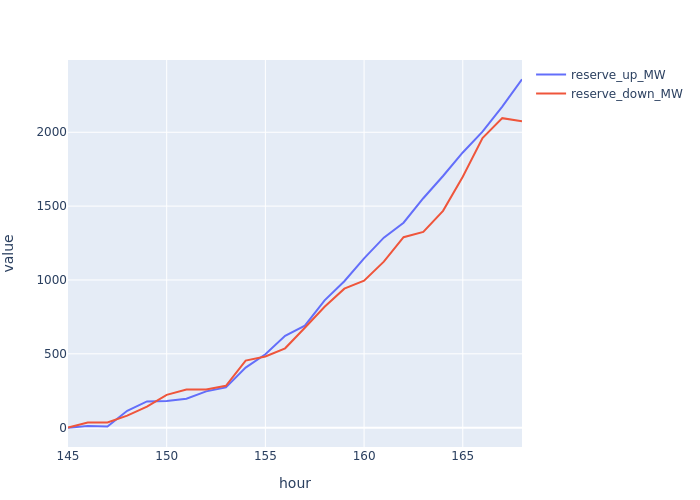

In [36]:
plot(stack(delta_reserve, [:reserve_up_MW, :reserve_down_MW]), x = :hour, y = :value, group = :variable)

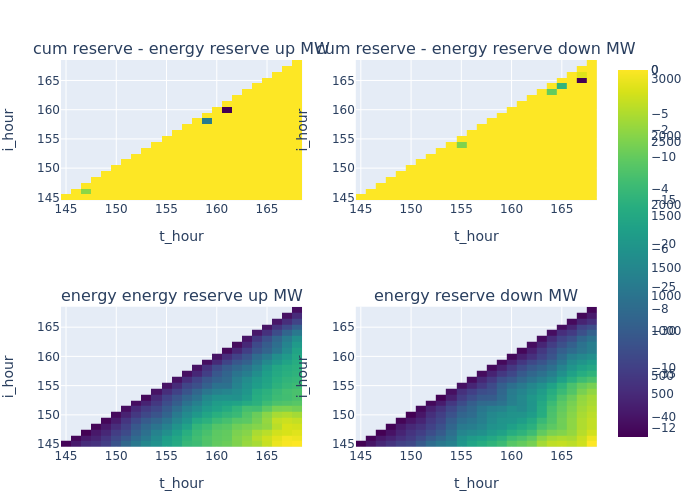

In [37]:
cumsum_required_reserve = required_energy_reserve[:,[:i_hour,:t_hour]] # cumualtive required reserve between i and t
f(i,t,df) = 
    (reserve_up_MW = sum(df[(df.hour.>=i).&&(df.hour.<=t),:reserve_up_MW]),
    reserve_down_MW = sum(df[(df.hour.>=i).&&(df.hour.<=t),:reserve_down_MW]),
    )
transform!(groupby(cumsum_required_reserve,[:i_hour, :t_hour]), [:i_hour, :t_hour] => ((i,t) -> f(i,t,required_reserve)) => AsTable)
;
# delta with energy reserve. 
delta = cumsum_required_reserve[:, [:reserve_up_MW, :reserve_down_MW]] .- required_energy_reserve[:, [:reserve_up_MW, :reserve_down_MW]]
delta.i_hour .= cumsum_required_reserve.i_hour
delta.t_hour .= cumsum_required_reserve.t_hour
delta[delta.reserve_up_MW .>=0,:reserve_up_MW].= 0
delta[delta.reserve_down_MW .>=0,:reserve_down_MW].= 0
# delta = filter(row -> all(x -> x <= 0, row[[:reserve_up_MW, :reserve_down_MW]]), delta)
;
p1 = PlotlyJS.plot(heatmap(x=delta.t_hour, y=delta.i_hour, z=delta.reserve_up_MW, colorscale="Viridis"), Layout(title="cum reserve - energy reserve up MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p2 = PlotlyJS.plot(heatmap(x=delta.t_hour, y=delta.i_hour, z=delta.reserve_down_MW, colorscale="Viridis"), Layout(title="cum reserve - energy reserve down MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p3 = PlotlyJS.plot(heatmap(x=required_energy_reserve.t_hour, y=required_energy_reserve.i_hour, z=required_energy_reserve.reserve_up_MW, colorscale="Viridis"), Layout(title="energy energy reserve up MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p4 = PlotlyJS.plot(heatmap(x=required_energy_reserve.t_hour, y=required_energy_reserve.i_hour, z=required_energy_reserve.reserve_down_MW, colorscale="Viridis"), Layout(title="energy reserve down MW", xaxis_title="t_hour", yaxis_title="i_hour"))
# p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNDIS, colorscale="Viridis"))
# p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNCH, colorscale="Viridis"))
[p1 p2; p3 p4]

In [38]:
include("../model/utils/empirical_mu.jl")
model, sol_1, sol_2 = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve)
;


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Set parameter MIPGap to value 1e-06
Set parameter MIPGap to value 1e-06
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 3888 rows, 4132 columns and 19376 nonzeros
Model fingerprint: 0x8eb69fa0
Model has 96 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 3e+03]
Presolve removed 1312 rows and 2028 columns
Presolve time: 0.01s
Pr

In [39]:
println(value(model[:epsilon_variance]))
println(value(model[:theta]))
println(value(model[:reserve]))
println(value(model[:slack]))
println(objective_value(model))

4.383777589454333e-6
5480.883080801364
9914.608608150005
98.9351105478816
-4334.790412417028


In [57]:
# function calculate_mu()
#     mu = []
#     for (θ, RES) in [(:θUPDIS, :RESUPDIS), (:θUPCH, :RESUPCH), (:θDNDIS, :RESDNDIS), (:θDNCH, :RESDNCH)]
#         aux = collect(skipmissing(sol_1[:, θ] ./ sol_1[:, RES]))
#         push!(mu, mean(values(aux)))
#     end
#     mu_df = DataFrame(mu = mu, variable = ["θUPDIS/RESUPDIS", "θUPCH/RESUPCH", "θDNDIS/RESDNDCH", "θDNCH/RESDNCH"])
#     return unstack(mu_df, :variable, :mu)
# end

function calculate_mu_t(sol_1)
    mu = DataFrame()
    for (θ, RES) in [(:θUPDIS, :RESUPDIS), (:θUPCH, :RESUPCH), (:θDNDIS, :RESDNDIS), (:θDNCH, :RESDNCH)]
        mu[!, Symbol("$θ/$RES")] = sol_1[:, θ] ./ sol_1[:, RES]
    end
    mu[!, :t] = sol_1.t
    mu = mu[1:end-1, :]
    return unstack(stack(mu, Not(:t)),:t, :value)
end
mu_t = calculate_mu_t(sol_1)



Row,variable,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168
,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,θUPDIS/RESUPDIS,1.0,0.989125,0.982353,0.953577,0.947167,0.946314,0.945208,0.937145,0.902825,0.912851,0.884546,0.836064,0.728256,0.497993,0.253311,0.128615,0.097833,0.0658326,0.0775153,0.0455958,0.0315824,0.0228021,0.0189878,0.0124918
2,θUPCH/RESUPCH,1.0,0.989181,0.983713,0.95367,0.952228,0.950587,0.942603,0.940043,0.91596,0.916962,0.882203,0.839994,0.750114,0.518216,0.256465,0.121986,0.094521,0.061338,0.0476086,0.0421184,0.0328173,0.0221123,0.0173984,0.0100194
3,θDNDIS/RESDNDIS,1.0,0.975755,0.967235,0.961857,0.960199,0.946495,0.951334,0.949332,0.925709,0.940737,0.924606,0.898606,0.873558,0.818082,0.682418,0.419889,0.255667,0.137458,0.12057,0.0600758,0.0450214,0.0393597,0.0333526,0.027721
4,θDNCH/RESDNCH,1.0,0.977628,0.967519,0.961747,0.957467,0.939684,0.953101,0.946295,0.913389,0.939386,0.927265,0.889697,0.857697,0.798866,0.676191,0.449342,0.276524,0.138276,0.112761,0.0614307,0.0464479,0.0419636,0.0362635,0.0332479


┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247


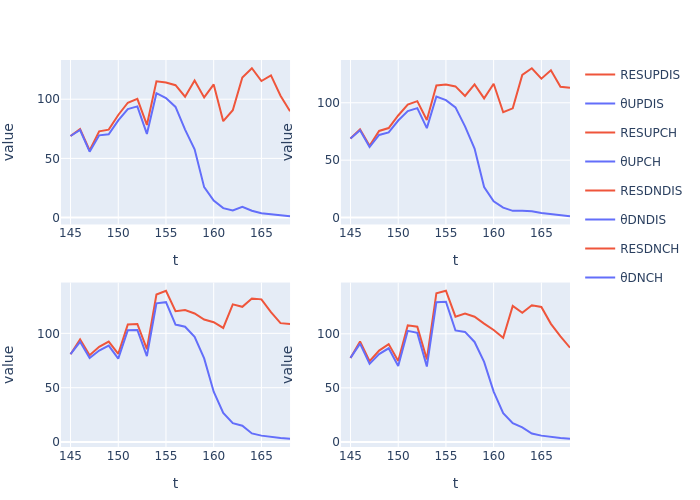

In [42]:
ks = [:θUPDIS,:RESUPDIS]
p1 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θUPCH,:RESUPCH]
p2 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θDNDIS,:RESDNDIS]
p3 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θDNCH,:RESDNCH]
p4 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

[p1 p2; p3 p4]

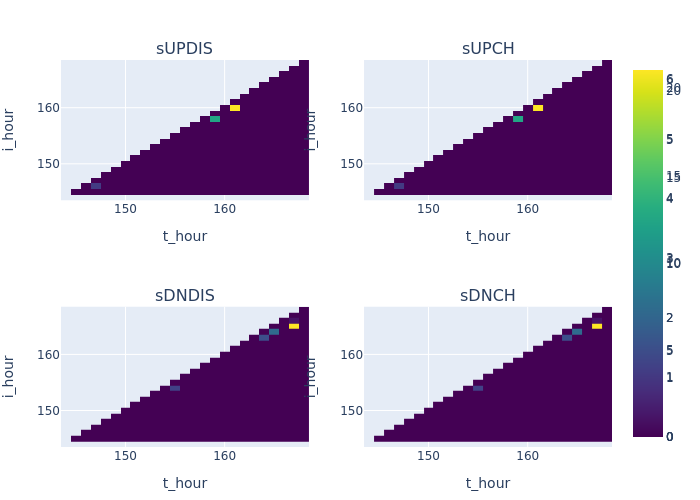

In [43]:
p1 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sUPDIS, colorscale="Viridis"), Layout(title="sUPDIS", xaxis_title="t_hour", yaxis_title="i_hour"))
p2 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sUPCH, colorscale="Viridis"), Layout(title="sUPCH", xaxis_title="t_hour", yaxis_title="i_hour"))
p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNDIS, colorscale="Viridis"), Layout(title="sDNDIS", xaxis_title="t_hour", yaxis_title="i_hour"))
p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNCH, colorscale="Viridis"), Layout(title="sDNCH", xaxis_title="t_hour", yaxis_title="i_hour"))
[p1 p2; p3 p4]

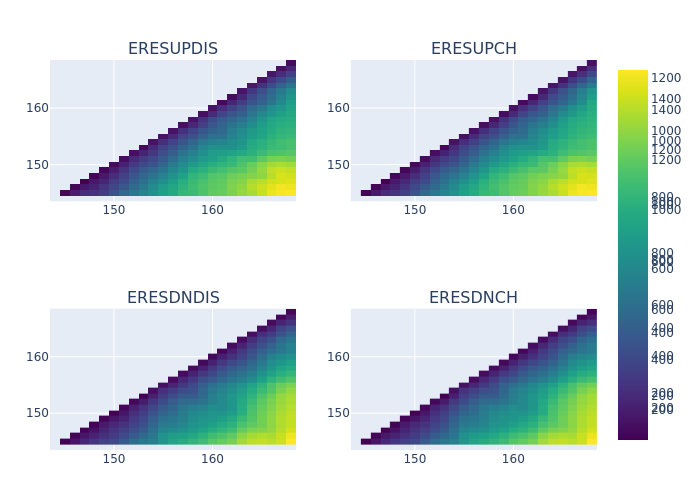

In [44]:
p1 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESUPDIS, colorscale="Viridis"), Layout(title="ERESUPDIS"))
p2 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESUPCH, colorscale="Viridis"), Layout(title="ERESUPCH"))
p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESDNDIS, colorscale="Viridis"), Layout(title="ERESDNDIS"))
p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESDNCH, colorscale="Viridis"), Layout(title="ERESDNCH"))
[p1 p2; p3 p4]

In [ ]:
rhos = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
day = 7

ε = 0.025
ρ = 0.8

mu_t_all = DataFrame()
for rho in rhos
    input_folder = "../input/base_case_increased_storage_energy_v7.$(rho).0"
    gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder, ε, ρ)
    required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
    model, sol_1, sol_2 = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve)
    mu_t = calculate_mu_t(sol_1)
    mu_t = insertcols(mu_t, 1, :rho => rho)
    append!(mu_t_all, mu_t)
end

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Set parameter MIPGap to value 1e-06
Set parameter MIPGap to value 1e-06
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 3888 rows, 4132 columns and 19376 nonzeros
Model fingerprint: 0xfde6fc55
Model has 96 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range   

In [62]:
mu_t_all

Row,rho,variable,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168
,Float64,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,0.0,θUPDIS/RESUPDIS,1.0,0.930756,0.872394,0.869425,0.865641,0.807074,0.721435,0.441892,0.20631,0.0976589,0.0850702,0.0359172,0.0584018,0.0493067,0.0711956,0.0263768,0.0271727,0.0190231,0.0147445,0.0139782,0.01007,0.0101647,0.0119459,0.00995879
2,0.0,θUPCH/RESUPCH,1.0,0.928619,0.887255,0.879592,0.858821,0.742946,0.64045,0.397627,0.193079,0.0870394,0.0785969,0.0357831,0.0538892,0.0502895,0.0259011,0.0237209,0.0231396,0.0170514,0.0142765,0.0129902,0.0118436,0.0101572,0.0104871,0.00801142
3,0.0,θDNDIS/RESDNDIS,1.0,0.937586,0.922057,0.900793,0.854315,0.826519,0.744651,0.664059,0.438774,0.211938,0.138809,0.0704944,0.071757,0.0651139,0.0427784,0.0369926,0.0324252,0.0202513,0.0225076,0.0195733,0.0135462,0.0136624,0.00916254,0.00943074
4,0.0,θDNCH/RESDNCH,1.0,0.938792,0.917542,0.899639,0.859869,0.880736,0.797901,0.704338,0.467185,0.224008,0.150184,0.0735165,0.0808812,0.0656075,0.0839024,0.0427629,0.0533436,0.0217603,0.0252389,0.0214914,0.0135455,0.0143971,0.00985708,0.0115456
5,0.1,θUPDIS/RESUPDIS,1.0,0.902125,0.872864,0.878415,0.822369,0.753046,0.664961,0.513766,0.289312,0.148435,0.141143,0.041128,0.035165,0.0382424,0.0296784,0.0255077,0.0237348,0.0146817,0.011557,0.0105159,0.00720528,0.00759152,0.00761154,0.00720432
6,0.1,θUPCH/RESUPCH,1.0,0.885097,0.841182,0.846476,0.801127,0.742733,0.649151,0.5147,0.290276,0.134412,0.190768,0.0379865,0.0295151,0.037599,0.0278286,0.0229618,0.0218297,0.014856,0.011079,0.00925469,0.00690815,0.00690646,0.00669837,0.00575299
7,0.1,θDNDIS/RESDNDIS,1.0,0.871996,0.834961,0.785271,0.763406,0.691107,0.514878,0.324452,0.148834,0.107904,0.0714157,0.067551,0.0483848,0.029625,0.029138,0.0181443,0.0182135,0.0188675,0.0118532,0.0112689,0.00999904,0.00732685,0.00867207,0.00538502
8,0.1,θDNCH/RESDNCH,1.0,0.890132,0.869349,0.821596,0.793937,0.716785,0.533605,0.320833,0.147702,0.118406,0.0744348,0.0600011,0.0481845,0.0305994,0.0329277,0.019263,0.0183407,0.0196663,0.0126527,0.0125781,0.0107136,0.00765023,0.0101558,0.00653991
9,0.2,θUPDIS/RESUPDIS,1.0,0.936366,0.911088,0.881894,0.884525,0.882402,0.803188,0.608197,0.27073,0.186958,0.0975115,0.0677239,0.0770396,0.0407728,0.0318116,0.0415699,0.0196412,0.0200383,0.0243179,0.0162797,0.0138419,0.0102186,0.00901048,0.00894717


In [47]:
# using CSV
# CSV.write("mu_t_all.csv", mu_t_all) 